Proyecto 1 - Felipe Sánchez 202187011-3

Objetivo: Reducir y calibrar una imagen científica astronómica original utilizando marcos de calibración estándar de un CCD.

Diagrama del proceso de reducción:

Parte 0: Abrir y organizar FITS.
Raw Images → Carpetas.

Parte 1: Construir Master Bias.
Bias → Master Bias.

Parte 2: Construir Master Dark.
Dark → Master Dark.

Parte 3: Construir Master Flat normalizado.
Flat → Master Flat (normalizado).

Parte 4: Reducción de imagen científica.
Imagen → Imagen calibrada.

Nota: Como cada paso depende del paso anterior, es importante mantener el orden del proceso detallado.

-----------------------------------------------------------------------------------------------------

Parte 0: Abrir y organizar FITS.

Para que en cada parte del proyecto el código se ejecute de manera óptima, conviene organizar en distintas carpetas las imágenes que trabajaremos. En el siguiente código se extrae desde el header de cada imagen información que nos permitirá clasificarla y así guardarla junto a otras del mismo tipo. También nos entregará datos que serán relevantes más adelante, como el tiempo de exposición y el filtro utilizado.

Ejecución: con el ciclo for accedemos a cada imagen de la carpeta Raw. Con "header.get" de astropy extraemos el tipo de imagen y luego se imprime en la pantalla.

Nota: como son pocas imágenes, se movieron manualmente a la carpeta correspondiente; el código solo se utilizó como una referencia y no como organizador.

In [1]:
#importar herramientas#
import os #modulo os para trabajar con carpetas, archivos y crear rutas.
from astropy.io import fits #modulo astropy para trabajar con imagenes astronómicas.

archivos = os.listdir("Raw") #lista de archivos dentro de la carpeta "Raw" (contiene las "image#.fit")
for archivo in archivos:
    ruta = os.path.join("Raw", archivo) #produce: "Raw/image.fit", una ruta de archivo
    hdul = fits.open(ruta) #abrir el archivo FITS, HDUList -> variable hdul
    header = hdul[0].header #extraer header de la primera extension
    print("Archivo:", archivo)
    print("IMAGETYP =", header.get("IMAGETYP", "No encontrado")) #buscar el tipo de imagen dentro del header
    print("EXPTIME  =", header.get("EXPTIME", "No encontrado")) #buscar el tiempo de exposicion dentro del header
    print("FILTER   =", header.get("FILTER", "No encontrado")) #buscar el filtro dentro del header
    print(" ")
        
    hdul.close()

Archivo: image1.fit
IMAGETYP = Bias Frame
EXPTIME  = 0.0
FILTER   = sloan_r
 
Archivo: image10.fit
IMAGETYP = Bias Frame
EXPTIME  = 0.0
FILTER   = sloan_r
 
Archivo: image11.fit
IMAGETYP = Dark Frame
EXPTIME  = 240.0
FILTER   = V
 
Archivo: image12.fit
IMAGETYP = Bias Frame
EXPTIME  = 0.0
FILTER   = sloan_r
 
Archivo: image13.fit
IMAGETYP = Light Frame
EXPTIME  = 100.0
FILTER   = sloan_r
 
Archivo: image14.fit
IMAGETYP = Flat Field
EXPTIME  = 5.0
FILTER   = sloan_r
 
Archivo: image15.fit
IMAGETYP = Bias Frame
EXPTIME  = 0.0
FILTER   = sloan_r
 
Archivo: image16.fit
IMAGETYP = Bias Frame
EXPTIME  = 0.0
FILTER   = sloan_r
 
Archivo: image17.fit
IMAGETYP = Flat Field
EXPTIME  = 10.0
FILTER   = sloan_r
 
Archivo: image18.fit
IMAGETYP = Bias Frame
EXPTIME  = 0.0
FILTER   = sloan_r
 
Archivo: image19.fit
IMAGETYP = Flat Field
EXPTIME  = 5.0
FILTER   = sloan_r
 
Archivo: image2.fit
IMAGETYP = Dark Frame
EXPTIME  = 200.0
FILTER   = sloan_r
 
Archivo: image3.fit
IMAGETYP = Flat Field
EXPTIME  =

Del código ejecutado tenemos:

9 Bias, 3 Dark, 4 Flat y 3 Science (Light Frame)

-----------------------------------------------------------------------------------------------------

Parte 1: Construir Master Bias.

El bias es un offset electrónico introducido por la electrónica del CCD. Se obtiene tomando imágenes con el obturador cerrado y tiempo de exposición cero, por lo que no contienen señal de luz y solo registran el nivel base del detector.

Ejecución: el siguiente código abre las imágenes cuyo header indica "IMAGETYP = Bias Frame" y guarda las matrices correspondientes en una lista. Posteriormente, la lista se convierte en un array usando la librería numpy para construir una nueva imagen llamada Master Bias. En esta imagen, cada píxel corresponde a la mediana de los valores de ese mismo píxel en todas las imágenes de bias. Utilizamos la mediana para que la imagen resultante no se vea afectada por los outliers (píxeles saturados o quemados), ya que con otro tipo de medición las gráficas podrían verse desplazadas a lugares que no representen una distribución adecuada.

El total de imágenes del tipo Bias son 9. De una de ellas (biasdata[0], que corresponde al archivo image1.fit) generaremos su histograma y analizaremos su distribución utilizando 25 bins.

Finalmente, del Master Bias mostraremos su imagen, generaremos su histograma utilizando 100 bins, estimaremos su media y su desviación estándar, que serán indicadas en la gráfica correspondiente.



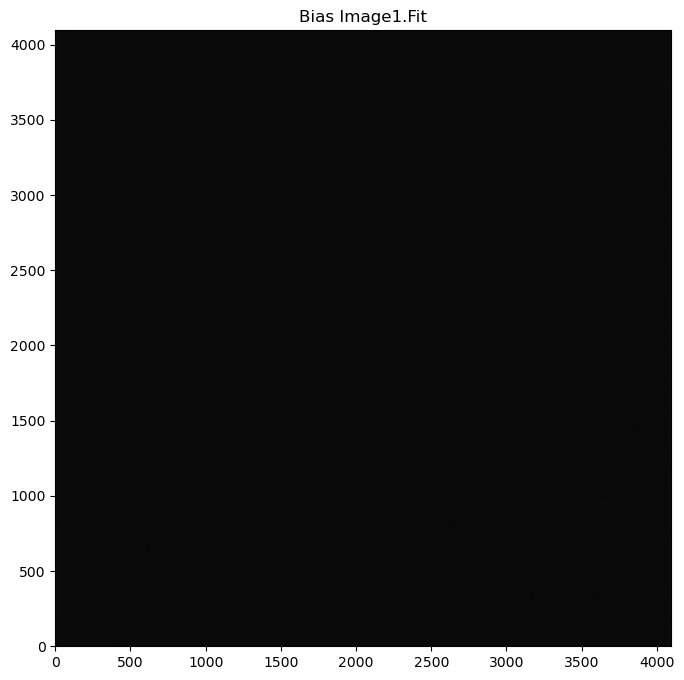

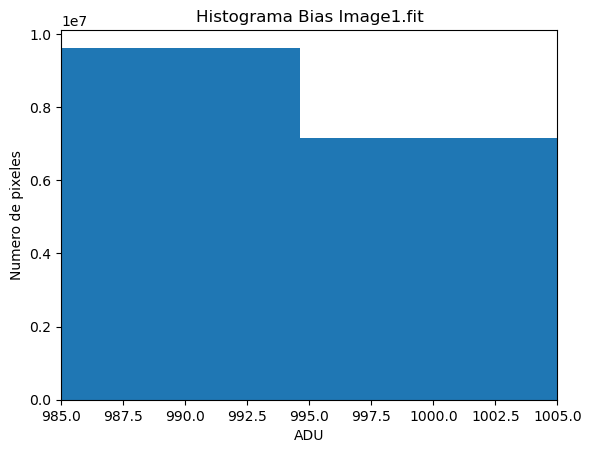

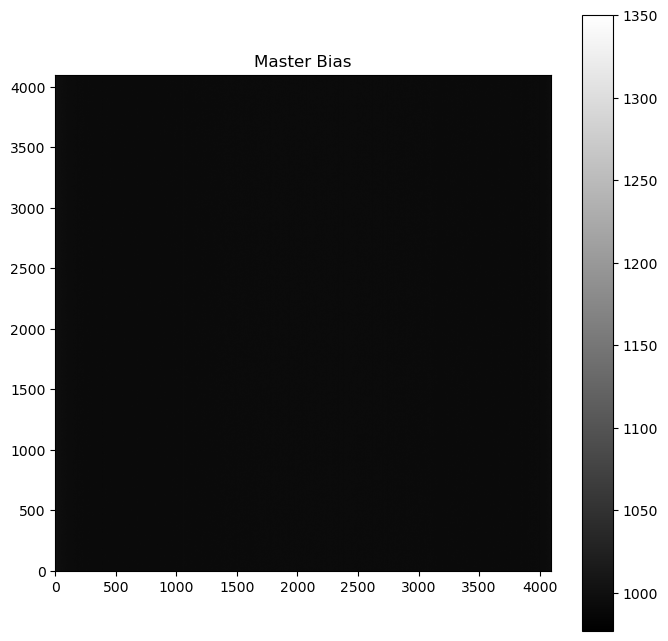

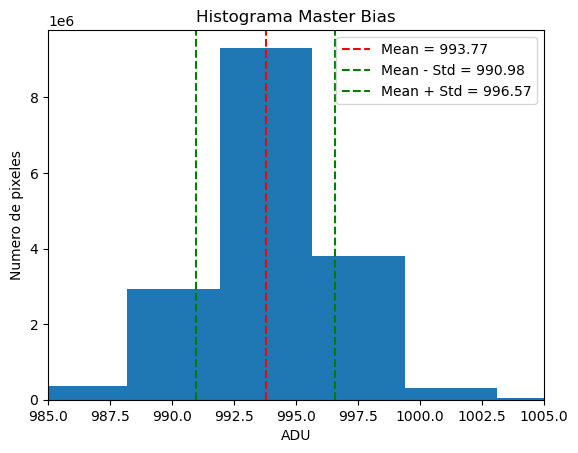

Std:  2.7950340529256215
Mean:  993.773767709732


In [61]:
import os
import numpy as np 
import matplotlib.pyplot as plt
from astropy.io import fits

biasfiles = os.listdir("Bias") # lista de imagenes en la carpeta Bias
biasdata = [] # lista vacia, guardara las matrices de las imagenes Bias (9 imagenes -> 9 matrices)

for archivo in biasfiles: 
    ruta = os.path.join("Bias", archivo) # ruta = Bias/image.fit     
    hdul = fits.open(ruta)
    data = hdul[0].data # matriz obtenida de cada fits (4096 x 4096) 
    biasdata.append(data) # agrega la matriz completa a la lista
    hdul.close()

biasstack = np.array(biasdata) # convierte la lista en un array 3D (9 imagenes, 4096 filas, 4096 columnas)
masterbias = np.median(biasstack, axis=0)  # Mediana pixel a pixel. El stack es (9, 4096, 4096) -> axis(0,1,2)
# "median(axis=0)" combinar imagenes, =1 filas, =2 columnas.
mean = np.mean(masterbias) # media
std = np.std(masterbias)   # desviacion estandar

#Bias individual
plt.figure(figsize=(8,8))
plt.imshow(biasdata[0], origin="lower", cmap="gray")
plt.title("Bias Image1.Fit")
plt.show()
# histograma 
plt.figure()
plt.hist(biasdata[0].flatten(), bins=25)
plt.xlabel("ADU")
plt.ylabel("Numero de pixeles")
plt.title("Histograma Bias Image1.fit")
plt.xlim(985, 1005)
plt.show()


# mostrar imagen del Master Bias
plt.figure(figsize=(8,8))
plt.imshow(masterbias, origin="lower", cmap="gray")
plt.colorbar()
plt.title("Master Bias")
plt.show()


# histograma del master bias
plt.figure()
plt.hist(masterbias.flatten(), bins=100)
plt.xlim(985, 1005)   # acorta el eje x


#Las siguientes 3 lineas del codigo fueron agregadas con IA#
plt.axvline(mean, color="red", linestyle="--", label=f"Mean = {mean:.2f}")
plt.axvline(mean - std, color="green", linestyle="--", label=f"Mean - Std = {mean-std:.2f}")
plt.axvline(mean + std, color="green", linestyle="--", label=f"Mean + Std = {mean+std:.2f}")
#############################################


plt.xlabel("ADU")
plt.ylabel("Numero de pixeles")
plt.title("Histograma Master Bias")
plt.legend()
plt.show()
print("Std: ", std)
print("Mean: ",mean)


El histograma del bias individual muestra la distribución de los valores de los píxeles, indicando cuántos píxeles presentan un cierto nivel de señal. Esta señal se expresa en ADU (Analog Digital Units), que corresponden a los valores digitales obtenidos al convertir la señal eléctrica generada por los electrones acumulados en el CCD durante el proceso.

-----------------------------------------------------------------------------------------------------

Parte 2: Construir Master Dark

Un Dark Frame es una imagen que se toma sin recibir luz y con el obturador cerrado. La diferencia con el Bias radica en la señal que miden, ya que el Dark Frame se toma con un tiempo de exposicion >0 y la señal termica del detector libera electrones los cuales interfieren con las imagenes que se tomen. Es necesario calcularlo ya que esta señal junto con la del Bias terminan interfiriendo con la luz que recibimos directamente de los cuerpos que registramos.

Ejecucion: el siguiente codigo se divide en dos partes. En una primera instancia veremos si los Dark Frame tienen un tiempo de exposicion similar, ya que generar una imagen del Master Dark con tiempos muy distintos entre si puede dar una imprecision en la distribucion de los pixeles de la imagen. Para ello imprimiremos el "EXPTIME" del header de cada imagen y veremos si sirven para el  posterior analisis. 

Ademas, conviene analizar la distribucion de ADU/s de los pixeles de cada imagen para seleccionar los que utilizaremos para armar el Master Dark: valores que esten fuera de la media en comparacion con las otras imagenes pueden alterar la distribucion que buscamos implementar. El siguiente codigo obtiene toda la informacion antes mencionada desde el header/data de cada imagen, tal como se hizo para armar el Master Bias.

image11.fit
IMAGETYP = Light Frame
EXPTIME = 100.0
FILTER = sloan_r
Mean = 0.00928708091378212
Std = 0.28010571504717174
negative pixels = 6604301


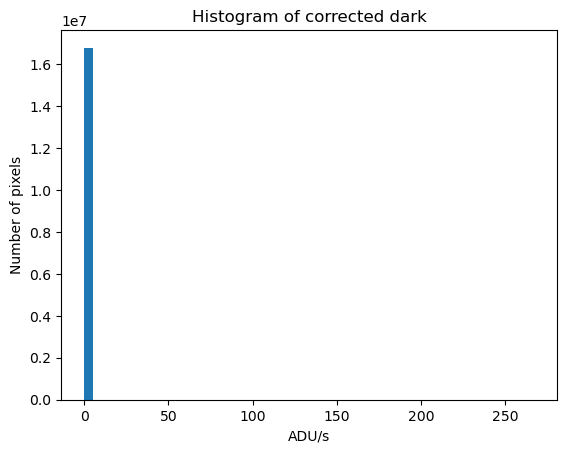

image2.fit
IMAGETYP = Light Frame
EXPTIME = 100.0
FILTER = sloan_r
Mean = -4.501758399009704
Std = 0.4548680273153781
negative pixels = 16761669


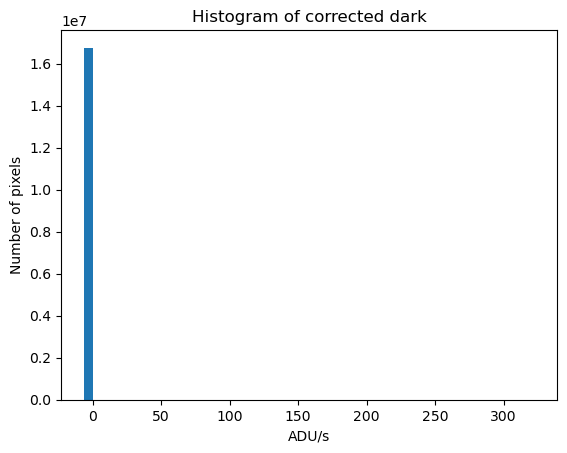

image8.fit
IMAGETYP = Light Frame
EXPTIME = 100.0
FILTER = sloan_r
Mean = 0.0090530041191313
Std = 0.30800766057991874
negative pixels = 6966988


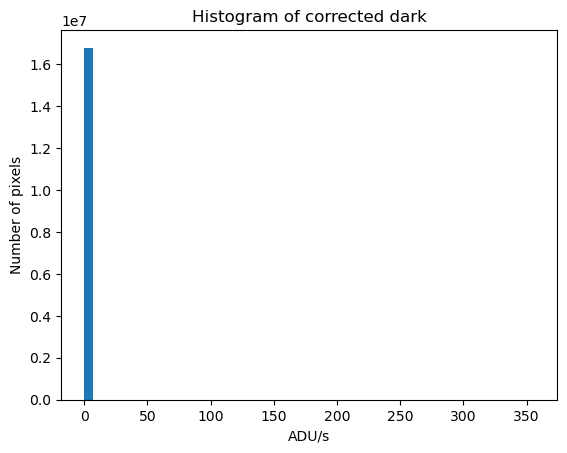

In [52]:
darkfiles = os.listdir("Dark")

for archivo in darkfiles:
    ruta = os.path.join("Dark", archivo)
    hdul = fits.open(ruta)
    data = hdul[0].data
    exptime = hdul[0].header.get("EXPTIME")
    hdul.close()

    darkcorrected = (data - masterbias) / exptime

    print(f"{archivo}")
    print("IMAGETYP =", header.get("IMAGETYP"))
    print("EXPTIME =", header.get("EXPTIME"))
    print("FILTER =", header.get("FILTER"))
    print("Mean =", np.mean(darkcorrected))
    print("Std =", np.std(darkcorrected))
    print("negative pixels =", np.sum(darkcorrected < 0))

    plt.figure()
    plt.hist(darkcorrected.flatten(), bins=50)
    plt.xlabel("ADU/s")
    plt.ylabel("Number of pixels")
    plt.title("Histogram of corrected dark")
    plt.show()

Como vimos en la primera parte del código, poseemos 3 Dark Files con tiempos de exposición de 240, 200 y 180 segundos. A pesar de la diferencia en los tiempos de exposición, el Dark Current (electrones liberados por procesos térmicos en el CCD) aumenta de forma lineal con el tiempo, por lo que en principio no debiese ser un impedimento para trabajarlos en conjunto. Sin embargo, con la información expuesta se concluye que esto no es suficiente para operar con todas ellas.

Al hacer el histograma de cada imagen, notamos que la "image2.fit" presenta valores negativos que desplazan la distribución de ADU/s con la que construiremos el Master Dark. También identificamos que el filtro utilizado en esta imagen es distinto al del resto. Si bien esto no debiese afectar directamente los resultados (ya que estamos trabajando con el obturador cerrado), puede indicarnos que hubo alguna diferencia en el proceso de lectura que explique esta variación en los valores entre las imágenes.

En la segunda parte del código construiremos el Master Dark utilizando las dos imágenes que presentan una media similar (0.009 ADU/s). Si bien son pocos datos para obtener una representación completamente precisa del Dark, consideramos que incluir una imagen que altera la distribución, desplazándola a valores muy negativos, es más perjudicial que trabajar con solo dos imágenes que son coherentes con los valores obtenidos anteriormente.

Ejecución: abrimos cada Dark File desde la carpeta donde fueron almacenados. De cada uno obtenemos su matriz y tiempo de exposición, los cuales son normalizados mediante:

"darkcorrected = (data - masterbias) / exptime"

Al igual que con el Master Bias, obtenemos una lista de matrices que ahora corresponden a los Dark normalizados. Luego, con numpy, podemos trabajar esta lista como una única matriz de dimensión (2, 4096, 4096) y producir una imagen donde cada píxel corresponde a la mediana de los píxeles que ocupan la misma posición en cada imagen. El código también muestra la media y la desviación estándar del Master Dark, además de generar su histograma.

Nota: el uso de la mediana para la construcción del Master Dark responde a la misma razón que en el Master Bias, evitar que outliers alteren la distribución de la imagen resultante.

Nota: ADU es el valor digital de cada pixel, en esta parte corresponde al valor del Dark-Bias. ADU/s representa la tasa de dark current del detector.

Master Dark Mean: 0.00917004251645671
Master Dark Std: 0.29299984518602007


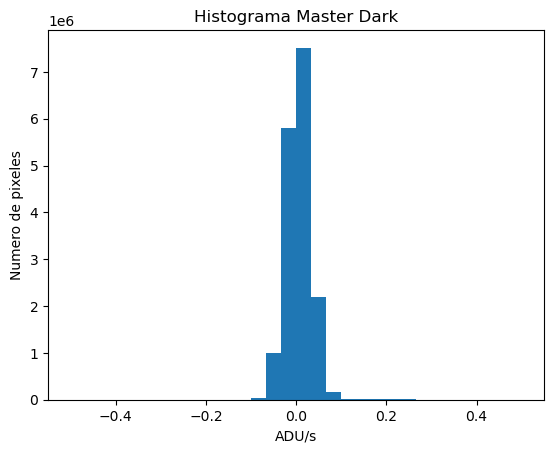

In [53]:
darkfiles = os.listdir("Dark")  # lista de imagenes en la carpeta Dark
darkdata = []  # lista vacia, guardara las matrices corregidas y normalizadas de las imagenes Dark
for archivo in darkfiles:
    if archivo == "image2.fit":
        continue
    ruta = os.path.join("Dark", archivo)  # ruta = Dark/image.fit
    hdul = fits.open(ruta)
    data = hdul[0].data  # matriz obtenida de cada fits
    header = hdul[0].header  # header del fits
    exptime = header.get("EXPTIME")  # tiempo de exposicion
    darkcorrected = (data - masterbias) / exptime  # dark corregido por Master Bias y normalizado por tiempo
    darkdata.append(darkcorrected)  # agrega la matriz corregida a la lista
    hdul.close()
darkstack = np.array(darkdata)  # convierte la lista en un array 3D
masterdark = np.median(darkstack, axis=0)  # mediana pixel a pixel
print("Master Dark Mean:", np.mean(masterdark))
print("Master Dark Std:", np.std(masterdark))
plt.figure()
plt.hist(masterdark.flatten(), bins=30, range=(-0.50, 0.50))
plt.xlabel("ADU/s")
plt.ylabel("Numero de pixeles")
plt.title("Histograma Master Dark")
plt.show()

--------------------------------------------------------------------------------------------
Parte 3: Construir Master Flat

Un Flat Frame es una imagen tomada a una fuente de luz uniforme. Esta imagen mide tanto la iluminación como la respuesta instrumental, considerando la sensibilidad de cada píxel a la señal producida.

Esta imagen incluye:

Viñeteo (bordes oscuros): producido por la geometría del sistema óptico; la luz entra de manera directa por el centro del lente, lo cual hace que esta zona esté más iluminada, en comparación con los bordes, donde la luz no llega de forma directa y es menos efectiva.

Polvo: se identifica en las imágenes como anillos oscuros.

Sensibilidad diferente en cada píxel: dado que el detector no es perfecto, cada píxel puede responder más o menos de lo que debería.

Imperfecciones: la propia construcción del lente puede provocar que la iluminación no sea completamente uniforme.

Construimos el Master Flat para obtener una versión más limpia de la imagen, que represente de mejor forma los problemas antes mencionados. Así, cuando reduzcamos la imagen, podremos mitigar los defectos del instrumento y observar una lectura más fiel de los objetos de estudio.

En la primera parte del código veremos las imágenes de los Flats que disponemos y seleccionaremos las que nos permitan construir el Master Flat más homogéneo posible. El criterio de selección será principalmente el filtro con el que las imágenes fueron tomadas.

Un filtro deja pasar solo cierto rango de longitudes de onda. Como estamos midiendo la respuesta que tiene el sistema a la luz que incide, distintos filtros terminan alterando en gran medida la información con la que luego construimos el Master Flat, produciendo errores de estimación.

El siguiente criterio es el tiempo de exposición. Como la cantidad de luz que recibe es mayor con el tiempo, algunos píxeles pueden saturarse y hacer que perdamos información real. En este caso, el Flat deja de representar correctamente los defectos que buscamos mitigar. De igual forma, un tiempo de exposición bajo implica una señal más débil, lo que puede provocar que el ruido sea más dominante en la imagen y que finalmente el Flat sea inestable.

El siguiente código abre cada imagen, nos muestra las características antes mencionadas y además nos permite visualizar el archivo.

Archivo: image14.fit
EXPTIME: 5.0
FILTER: sloan_r
ADU maximo: 25047
Mean: 16071.309046268463
Median: 16363.0


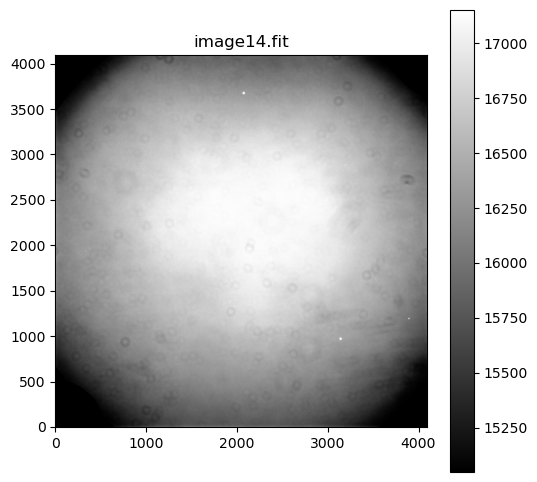

Archivo: image17.fit
EXPTIME: 10.0
FILTER: sloan_r
ADU maximo: 25089
Mean: 7283.861391425133
Median: 7407.0


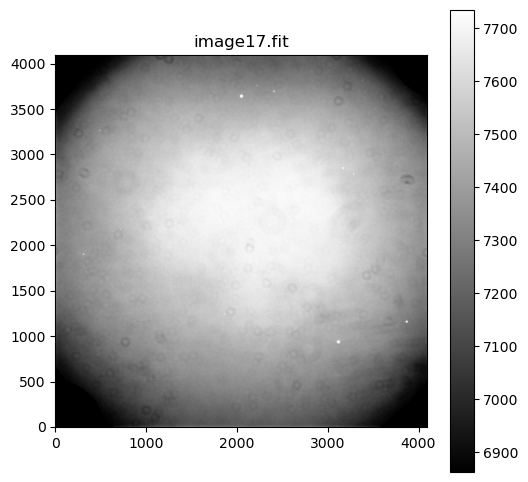

Archivo: image19.fit
EXPTIME: 5.0
FILTER: sloan_r
ADU maximo: 18515
Mean: 8916.221149086952
Median: 9069.0


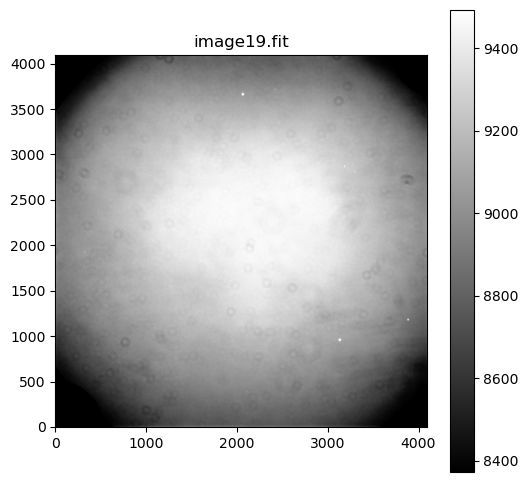

Archivo: image3.fit
EXPTIME: 5.0
FILTER: sloan_r
ADU maximo: 16102
Mean: 6020.10718870163
Median: 6117.0


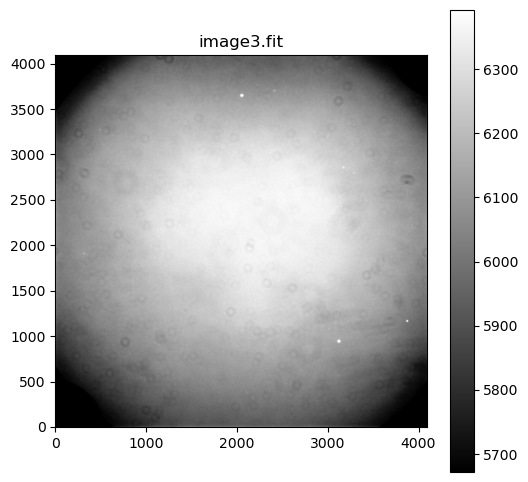

In [57]:
flatfiles = os.listdir("Flat")

for archivo in flatfiles:
    ruta = os.path.join("Flat", archivo)
    hdul = fits.open(ruta)
    data = hdul[0].data
    header = hdul[0].header

    print("Archivo:", archivo)
    print("EXPTIME:", header.get("EXPTIME"))
    print("FILTER:", header.get("FILTER"))
    plt.figure(figsize=(6,6))
    plt.imshow(data, origin="lower", cmap="gray", vmin = np.percentile(data, 5),vmax = np.percentile(data, 95))
    m = np.max(data)   
    print("ADU maximo:", m)
    print("Mean:", np.mean(data))
    print("Median:", np.median(data))
    plt.colorbar()
    plt.title(f"{archivo}")
    plt.show()

    hdul.close()

Se puede identificar que en las 4 imágenes tomadas hay ciertos patrones que se repiten visualmente. Podemos notar el centro más brillante y los bordes más oscuros; como mencionamos antes, esto corresponde al viñeteo y a la estructura del lente, que concentra la mayor cantidad de luz en el centro de la imagen. También se observan muchas estructuras circulares, que corresponden a polvo o motas en el sistema óptico.

Lo más llamativo en las imágenes son los 3 puntos blancos que aparecen en cada una de ellas. Se observa además que el valor máximo de ADU alcanzado (el mayor entre todas las imágenes) es de 25089 ADU, mientras que el valor típico de saturación es de 65535 ADU, por lo que se puede descartar que se trate de saturación de píxeles. Estos 3 puntos corresponden a estrellas: el telescopio estaba apuntando al cielo y no a una pantalla uniforme, lo que provocó su aparición en la imagen. Esto se deduce ya que se mantienen en la misma posición en todas las imágenes, por lo que no corresponden a píxeles calientes ni a eventos aleatorios. Si bien esto afecta la reducción, las estrellas son débiles en comparación con el fondo y, al normalizar, su efecto puede reducirse. Además, el uso de la mediana permite mitigar su impacto en la distribución. Por lo tanto, aunque no son flats ideales, siguen siendo útiles para construir el Master Flat.

Se decidió trabajar únicamente con las imágenes que tienen un tiempo de exposición de 5 segundos y descartar la de 10 segundos. Los flats deben ser consistentes en iluminación y tiempos de lectura, una diferencia entre ellos podría introducir sesgos que alteren el resultado.

Ejecucion: El siguiente codigo abre cada archivo Flat y extrae su imagen. Produce dos histogramas: el primero contiene la imagen de cada Flat, y el segundo solo de los Flat seleccionados.

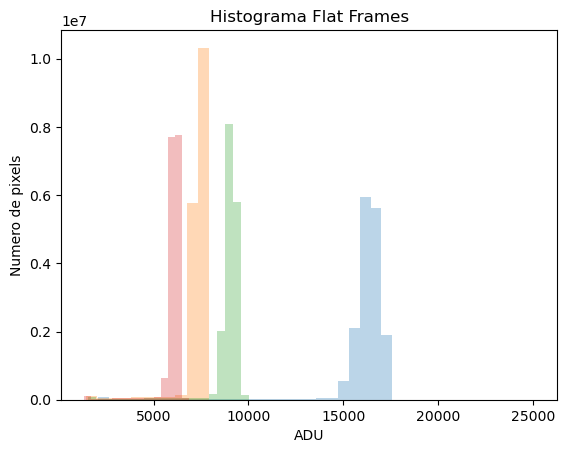

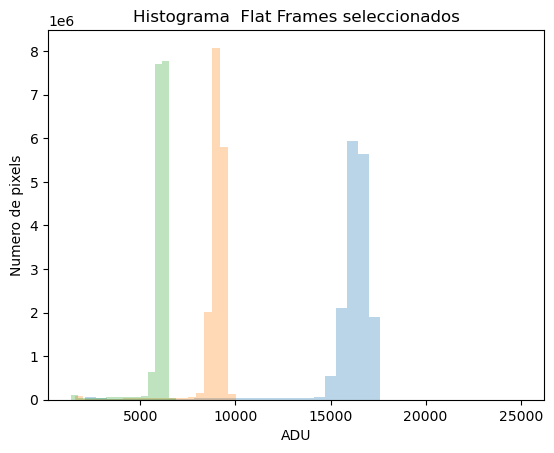

In [44]:
flatfiles = os.listdir("Flat")
# Histograma para todos los Flat Frames
for archivo in flatfiles:
    ruta = os.path.join("Flat", archivo)
    hdul = fits.open(ruta)
    data = hdul[0].data
    header = hdul[0].header
    exptime = header.get("EXPTIME")
    filtro = header.get("FILTER")
    if exptime == 5 or exptime==10:
        plt.hist(data.flatten(), bins=40, alpha=0.3)
    hdul.close()
plt.xlabel("ADU")
plt.ylabel("Numero de pixels")
plt.title("Histograma Flat Frames")
plt.show()

# Histograma solo para los Flat seleccionados (tiempo de exposicion igual a 5 segundos)
for archivo in flatfiles:
    ruta = os.path.join("Flat", archivo)
    hdul = fits.open(ruta)
    data = hdul[0].data
    header = hdul[0].header
    exptime = header.get("EXPTIME")
    filtro = header.get("FILTER")
    if exptime == 5:
        plt.hist(data.flatten(), bins=40, alpha=0.3)
    hdul.close()
plt.xlabel("ADU")
plt.ylabel("Numero de pixels")
plt.title("Histograma  Flat Frames seleccionados")
plt.show()

Ejecución: en esta segunda parte del código combinamos cada Flat normalizado para crear el Master Flat normalizado. El siguiente código abre cada archivo de la carpeta Flat y, dependiendo del tiempo de exposición de la imagen (solo los de 5 segundos), los corrige. Primero de la forma:

flatcorrected = data - masterbias - masterdark * exptime

luego normalizamos la relación anterior de la forma:

flatnormalized = flatcorrected / np.mean(flatcorrected)

El Master Flat es la combinación de todas estas imágenes corregidas y normalizadas. Se ubica en primera instancia en la variable "flatdata", que es una lista de matrices. Con numpy array podemos transformarla en una única matriz y luego usar la mediana para cada píxel en cada posición de las distintas imágenes; así, el código construye el Master Flat. A continuación, se mostrará un histograma del Master Flat y los valores tanto de la media como de la mediana.

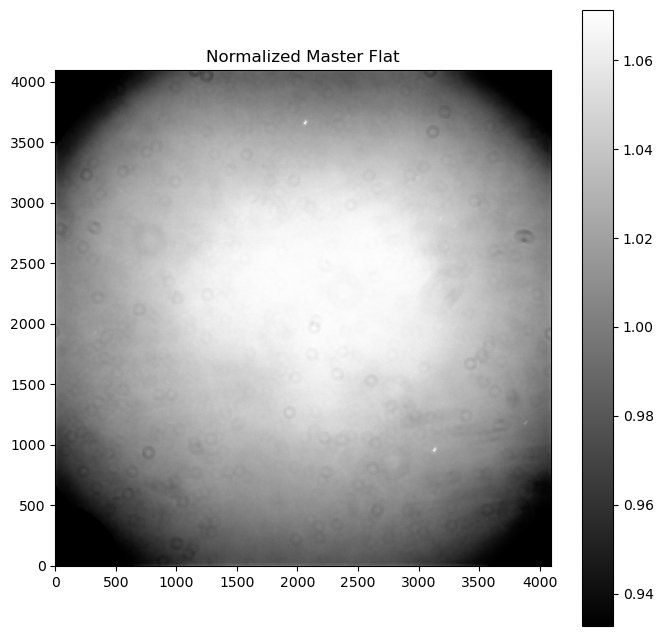

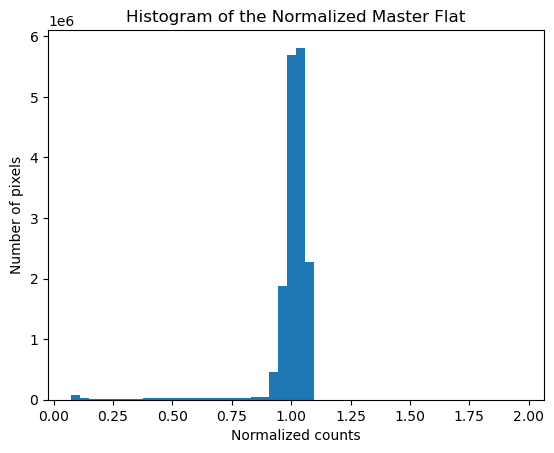

Mean:  0.9999792493027809
Std:  0.11521795097506238


In [60]:
flatfiles = os.listdir("Flat")
flatdata = []
for archivo in flatfiles:
    ruta = os.path.join("Flat", archivo)
    hdul = fits.open(ruta)
    data = hdul[0].data
    header = hdul[0].header
    exptime = header.get("EXPTIME")
    filtro = header.get("FILTER")
    if exptime == 5:
        flatcorrected = data - masterbias - masterdark * exptime
        flatnormalized = flatcorrected / np.mean(flatcorrected)
        flatdata.append(flatnormalized)
    hdul.close()
flatstack = np.array(flatdata)
normalizedflat = np.median(flatstack, axis=0)
plt.figure(figsize=(8,8))
plt.imshow(normalizedflat, origin="lower", cmap="gray", vmin = np.percentile(normalizedflat, 5),vmax = np.percentile(normalizedflat, 95))
plt.colorbar()
plt.title("Normalized Master Flat")
plt.show()

meanflat = np.mean(normalizedflat)
stdflat = np.std(normalizedflat)

plt.figure()
plt.hist(normalizedflat.flatten(), bins=50)
plt.xlabel("Normalized counts")
plt.ylabel("Number of pixels")
plt.title("Histogram of the Normalized Master Flat")
plt.show()

print("Mean: ",meanflat)
print("Std: ",stdflat)

El objetivo del proyecto es calibrar una imagen científica. Como vimos durante el proceso, hay varios factores que alteran la información que recibimos: el offset electrónico de la CCD, el ruido producido por los electrones que resultan de la señal térmica del detector, la diferencia de recepción entre píxeles y los defectos del telescopio. Para todas estas situaciones generamos imágenes que, al restarlas a la original, podrán darnos una visión más fiel de las lecturas hechas.

Ejecución: El código se divide en 3 partes. En la primera abriremos cada imagen y obtendremos su tiempo de exposición y el filtro con el que se hizo la lectura; esto nos servirá para saber con cuántas imágenes contamos y cómo podemos calibrar. En las otras dos partes haremos la reducción de la imagen.

In [9]:
sciencefiles = os.listdir("Science")

for archivo in sciencefiles:
    ruta = os.path.join("Science", archivo)
    hdul = fits.open(ruta)
    header = hdul[0].header

    print("Archivo:", archivo)
    print("EXPTIME:", header.get("EXPTIME"))
    print("FILTER:", header.get("FILTER"))
    print("IMAGETYP:", header.get("IMAGETYP"))
    print(" ")

    hdul.close()


Archivo: image13.fit
EXPTIME: 100.0
FILTER: sloan_r
IMAGETYP: Light Frame
 
Archivo: image5.fit
EXPTIME: 100.0
FILTER: sloan_r
IMAGETYP: Light Frame
 
Archivo: image9.fit
EXPTIME: 100.0
FILTER: sloan_r
IMAGETYP: Light Frame
 


En esta segunda parte, abrimos una imagen puntual (en este caso "image13.fit") y hacemos la reduccion mediante la formula:

sciencecorrected = (scienceraw - masterbias - masterdark * exptime) / normalizedflat

Generaremos los histogramas tanto de la imagen corregida y la cruda, para notar sus diferencias. Tambien visualizaremos la imagen residual, que es lo que estamos limpiando de la imagen original.

Archivo: image13.fit
EXPTIME: 100.0
FILTER: sloan_r


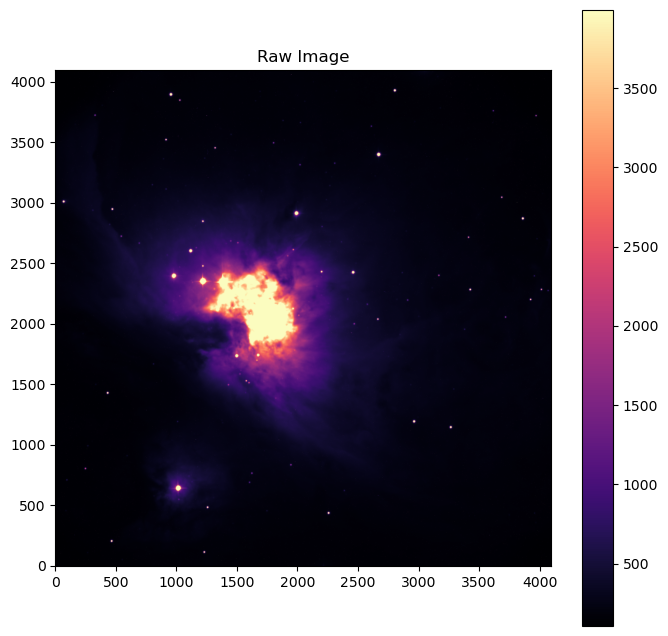

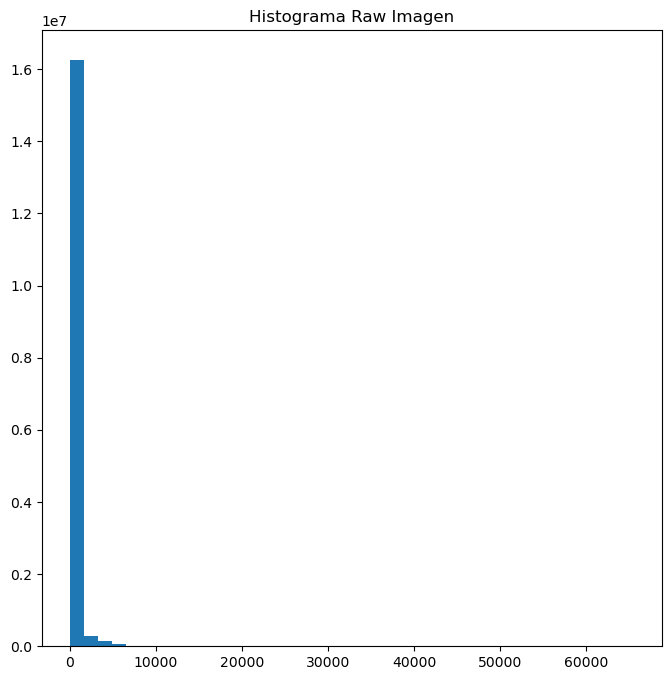

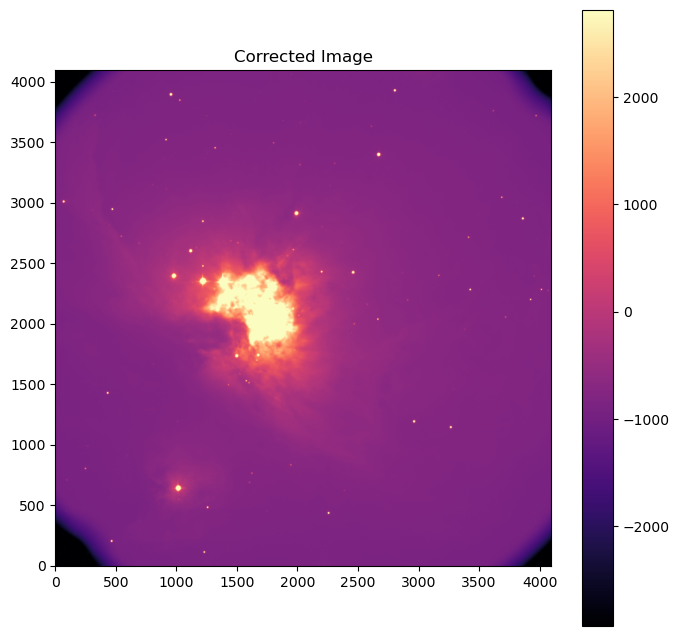

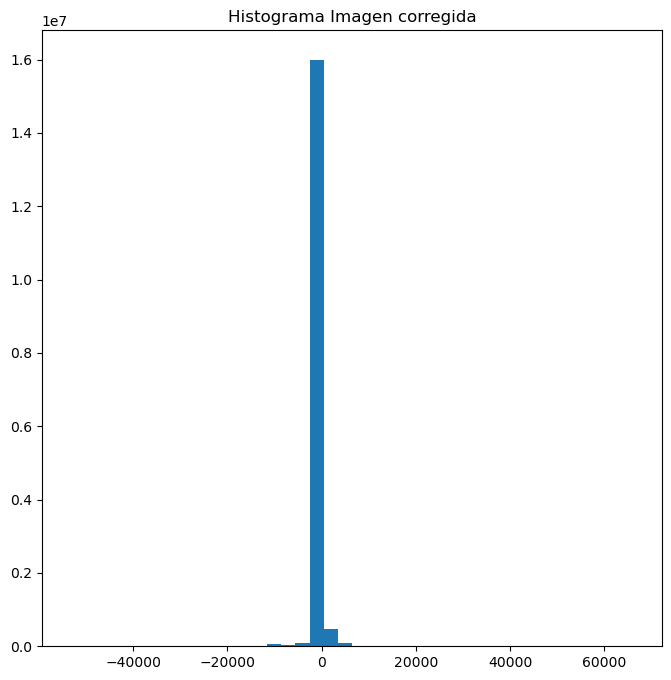

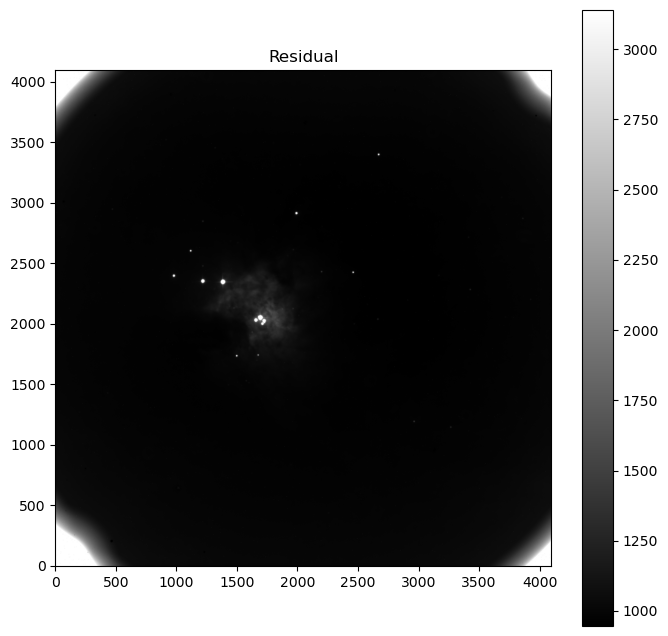

Scienceraw mean:  410.1061515212059
Master Bias mean:  993.773767709732
Pixeles negativos en science corrected: 15782467


In [65]:
archivo = sciencefiles[0]   
ruta = os.path.join("Science", archivo)
hdul = fits.open(ruta)
scienceraw = hdul[0].data
header = hdul[0].header
exptime = header.get("EXPTIME")
filtro = header.get("FILTER")
hdul.close()


#ATENCION A LA SIGUIENTE VARIABLE
sciencecorrected = (scienceraw - masterbias - masterdark * exptime) / normalizedflat

residual = scienceraw - sciencecorrected
print("Archivo:", archivo)
print("EXPTIME:", exptime)
print("FILTER:", filtro)

vminraw = np.percentile(scienceraw, 1)
vmaxraw = np.percentile(scienceraw, 99)

vmincorr = np.percentile(sciencecorrected, 1)
vmaxcorr = np.percentile(sciencecorrected, 99)

vminres = np.percentile(residual, 1)
vmaxres = np.percentile(residual, 99)

plt.figure(figsize=(8,8))
plt.imshow(scienceraw, origin="lower", cmap="magma", vmin=vminraw, vmax=vmaxraw)
plt.colorbar()
plt.title("Raw Image")
plt.show()

plt.figure(figsize=(8,8)) 
plt.hist(scienceraw.flatten(), bins=40)
plt.title("Histograma Raw Imagen")
plt.show()

plt.figure(figsize=(8,8))
plt.imshow(sciencecorrected, origin="lower", cmap="magma", vmin=vmincorr, vmax=vmaxcorr)
plt.colorbar()
plt.title("Corrected Image")
plt.show()

plt.figure(figsize=(8,8))
plt.hist(sciencecorrected.flatten(), bins=40)
plt.title("Histograma Imagen corregida")
plt.show()

plt.figure(figsize=(8,8))
plt.imshow(residual, origin="lower", cmap="gray", vmin=vminres, vmax=vmaxres)
plt.colorbar()
plt.title("Residual")
plt.show()

print("Scienceraw mean: ", np.mean(scienceraw))
print("Master Bias mean: ", np.mean(masterbias))
print("Pixeles negativos en science corrected:", np.sum(sciencecorrected < 0))

A partir de los histogramas podemos notar que la distribución de ADU de los píxeles es muy distinta. La imagen corregida presenta una gran cantidad de píxeles negativos, esta diferencia es producida por la resta incluida en la corrección que incorpora el Master Bias. La media de ADU de la imagen original es de 410, mientras que la media del Master Bias es de 993, por lo que las escalas de señal entre ambas no son compatibles y la sustracción desplaza la distribución hacia valores negativos. Esto también se refleja en la imagen corregida: la iluminación excesiva en el centro obstruye la observación y los bordes se ven oscuros.

En esta tercera parte volveremos a realizar la corrección, pero sin incluir el Master Bias. Si bien no es lo ideal, la diferencia no es despreciable, y para continuar con la reducción es necesario hacer esta modificación para obtener un resultado razonable.

Archivo: image13.fit
EXPTIME: 100.0
FILTER: sloan_r


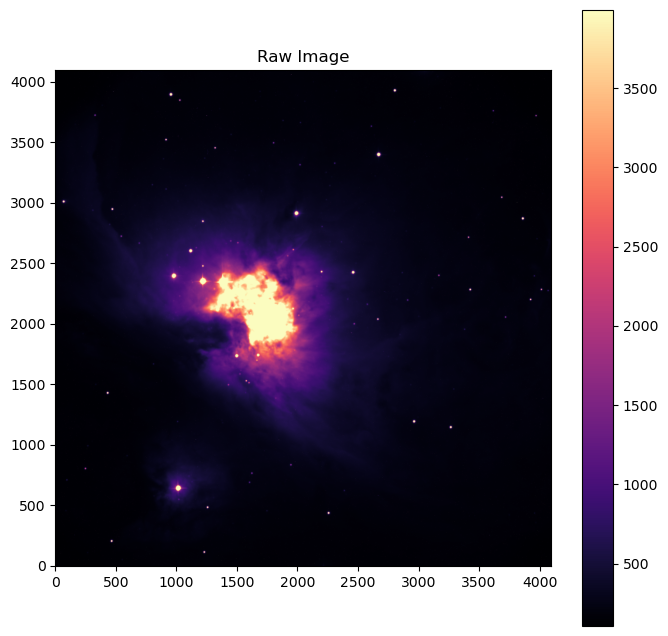

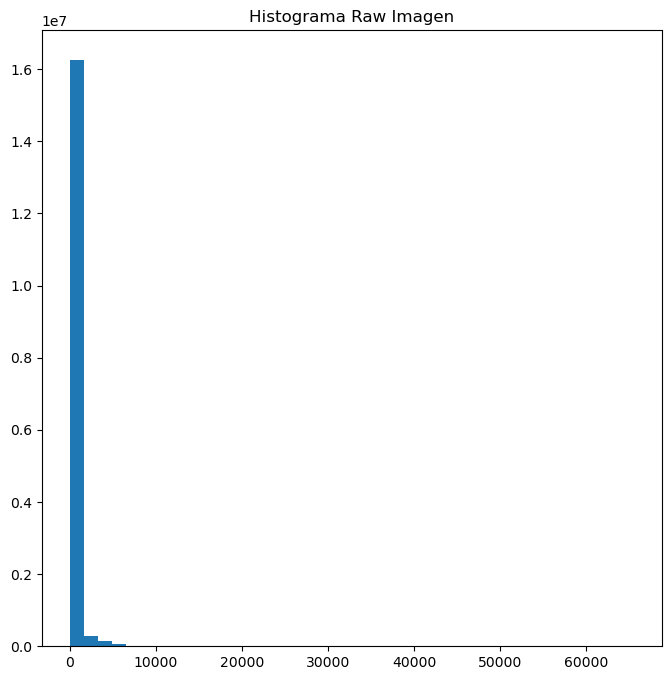

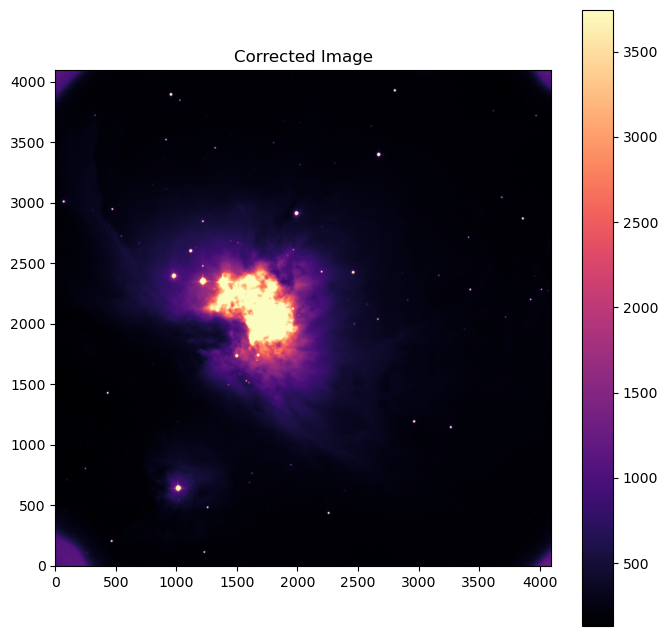

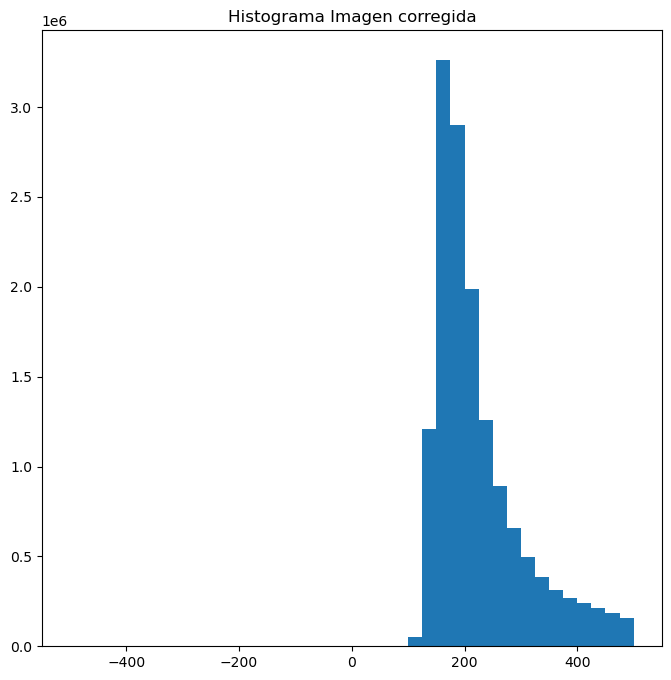

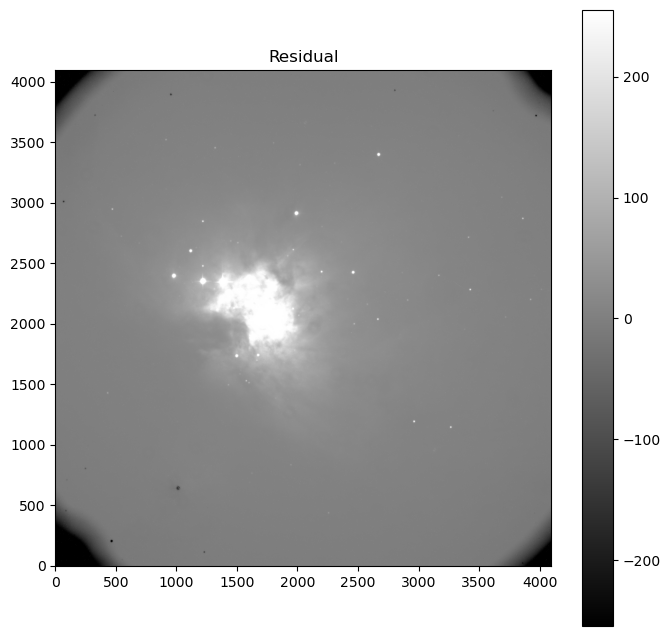

Pixeles negativos en science corrected: 3350


In [68]:
archivo = sciencefiles[0]   
ruta = os.path.join("Science", archivo)
hdul = fits.open(ruta)
scienceraw = hdul[0].data
header = hdul[0].header
exptime = header.get("EXPTIME")
filtro = header.get("FILTER")
hdul.close()


#ATENCION A LA SIGUIENTE VARIABLE"
sciencecorrected = (scienceraw - masterdark * exptime) / normalizedflat

residual = scienceraw - sciencecorrected
print("Archivo:", archivo)
print("EXPTIME:", exptime)
print("FILTER:", filtro)

vminraw = np.percentile(scienceraw, 1)
vmaxraw = np.percentile(scienceraw, 99)

vmincorr = np.percentile(sciencecorrected, 1)
vmaxcorr = np.percentile(sciencecorrected, 99)

vminres = np.percentile(residual, 1)
vmaxres = np.percentile(residual, 99)

plt.figure(figsize=(8,8))
plt.imshow(scienceraw, origin="lower", cmap="magma", vmin=vminraw, vmax=vmaxraw)
plt.colorbar()
plt.title("Raw Image")
plt.show()

plt.figure(figsize=(8,8)) 
plt.hist(scienceraw.flatten(), bins=40)
plt.title("Histograma Raw Imagen")
plt.show()

plt.figure(figsize=(8,8))
plt.imshow(sciencecorrected, origin="lower", cmap="magma", vmin=vmincorr, vmax=vmaxcorr)
plt.colorbar()
plt.title("Corrected Image")
plt.show()

plt.figure(figsize=(8,8))
plt.hist(sciencecorrected.flatten(), bins=40,range=(-500, 500))
plt.title("Histograma Imagen corregida")
plt.show()

plt.figure(figsize=(8,8))
plt.imshow(residual, origin="lower", cmap="gray", vmin=vminres, vmax=vmaxres)
plt.colorbar()
plt.title("Residual")
plt.show()


print("Pixeles negativos en science corrected:", np.sum(sciencecorrected < 0))

Al comparar la imagen cruda con la imagen corregida, se observa que las diferencias no son extremadamente evidentes a simple vista, pero sí relevantes. En la imagen corregida, el fondo se vuelve más uniforme y oscuro, reduciendo los efectos instrumentales. Además, se logra un mayor contraste en la región central, permitiendo distinguir mejor las estructuras de la nebulosa. Las regiones más débiles también se vuelven más visibles, y las estrellas presentan mayor nitidez. Por otro lado, se observa una sobrecorrección en los bordes, lo que genera zonas más brillantes en las esquinas. Estos bordes brillantes se producen por la división con el Master Flat, que resalta estas zonas originalmente más oscuras. Esto también es apreciable en la imagen residual, donde se corrige la iluminación excesiva en el centro y la oscuridad de los bordes presentes en la imagen anterior.

En los histogramas generados, se puede notar que la distribución es mucho más consistente que antes, y que la cantidad de píxeles negativos es menor en esta ocasión.

---------------------------------------------------------------------------------

La rigurosidad es un criterio fundamental de toda ciencia. En este proyecto, el objetivo era reducir las imprecisiones que se producen en las imágenes, debido principalmente a la naturaleza de los sensores que traducen los fotones en señales digitales, y también a la estructura física del instrumento con el que se toman las imágenes. En este proceso se descartaron distintos archivos disponibles como Bias, Dark y Flat, con el fin de optimizar la reducción final. De esta forma, podemos visualizar de mejor manera los cuerpos que estudiamos.

La imagen final corresponde a la Nebulosa de Orión (M42), uno de los objetos más antiguos observados en el cielo. Se puede notar un centro muy luminoso y gas extendido con forma irregular. Es una región de formación estelar, y se aprecia un campo de estrellas a su alrededor. Lo que por muchos años fue solo una mancha difusa, con la instrumentación actual se entiende como algo mucho más complejo, lo que cambia nuestra interpretación del universo.

Nota final: el uso de IA dentro de los códigos ejecutados se limitó a la Parte 1, donde se indicaron las líneas generadas. Fuera de ello, solo se utilizó para corregir la puntuación, y no en la redacción de los párrafos escritos.